In [1]:
# Code Carbon

from codecarbon import OfflineEmissionsTracker

# stop a tracker left running from a previous run of this cell
try:
    tracker.stop()
except NameError:
    pass          # no tracker defined yet (first run)
except Exception:
    pass          # partially-initialized/already-stopped tracker; ignore

tracker = OfflineEmissionsTracker(country_iso_code="USA", log_level="error", project_name="College Baseball XGBoost")
tracker.start()

[codecarbon INFO @ 13:09:59] offline tracker init
[codecarbon WARNING @ 13:09:59] Multiple instances of codecarbon are allowed to run at the same time.


In [2]:
# Imports

import pandas as pd
import numpy as np
import re
import xgboost as xgb
import json
import os
import pynvml
import shap
import shap
from difflib import get_close_matches, SequenceMatcher
from sklearn.model_selection import train_test_split
from scipy.special import expit
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import plotly.express as px
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    average_precision_score, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, classification_report,
    confusion_matrix, mean_absolute_error, r2_score
)

# 2026 MLB Draft Prediction (V8)

Trains the draft pipeline on historical seasons (2021-2025, which have known draft outcomes) and applies it to the **2026** class to produce a full predicted draft board.

Differences from V7:
- Predicts the unlabeled 2026 cohort instead of evaluating a held-out year.
- The rank / signing-bonus / slot models are **stats-only** (no MLB-API position/height/weight features), since those don't exist until a player is actually drafted.
- Accuracy metrics (classification report, PR/ROC-AUC, Spearman/MAE, head-to-head vs the actual draft) are removed -- the 2026 draft hasn't happened, so there's nothing to score against.

In [3]:
# Combined batting+pitching+team dataset with 2026 appended (built by build_2026_combined.py)
DATA_FILE = 'batting_pitching_combined_with_rpi_2026.csv'
PREDICT_YEAR = 2026
year_col = 'year'
test_year = PREDICT_YEAR  # alias: 'year < test_year' selects the historical training pool

df = pd.read_csv(DATA_FILE, delimiter=',')
print(f"Loaded {len(df)} rows; {(df[year_col] == PREDICT_YEAR).sum()} are {PREDICT_YEAR}.")
print(df[year_col].value_counts().sort_index())

Loaded 20220 rows; 3492 are 2026.
year
2021    3146
2022    3374
2023    3463
2024    3359
2025    3386
2026    3492
Name: count, dtype: int64


In [4]:
# ---- Draft-eligibility signal (input to the post-prediction board filter) ----
# MLB rule of thumb: a college player is draft-eligible if he has completed his
# junior year (i.e. is in his 3rd+ college season) OR is at least 21 within ~45
# days of the draft. The classifier/rank models are trained purely on performance
# and have NO notion of eligibility, so a dominant freshman/sophomore can rank
# highly despite being ineligible. We therefore build a per-player college-season
# count and apply eligibility as a post-hoc filter (never as a model feature).
#
# Season counts come from the "no-minimum" FanGraphs leaderboards, which include
# seasons below the PA/IP qualification cut that the main qualified file drops --
# this recovers early-career seasons (e.g. a lightly-used freshman year) that the
# qualified stats miss. We union those with the modeling dataset's own seasons
# (which adds the 2026 season and any qualified-only years).
import glob

NOMIN_GLOBS = [
    '../ncaa_battingNoMinCSV/batting_combined_all.csv',
    '../ncaa_pitchingNoMinCSV/pitching_combined_all.csv',
]

def _add_seasons(path, seasons):
    d = pd.read_csv(path, encoding='utf-8-sig')
    d.columns = [c.strip().lower() for c in d.columns]
    if 'playerid' not in d.columns or 'year' not in d.columns:
        print(f'  !! {path}: missing playerid/year, skipped')
        return
    pids = d['playerid'].astype(str).str.strip()
    for pid, yr in zip(pids, d['year']):
        if pid and pid.lower() != 'nan' and pd.notna(yr):
            seasons.setdefault(pid, set()).add(int(yr))

seasons_by_pid = {}
for _g in NOMIN_GLOBS:
    for _p in glob.glob(_g):
        _add_seasons(_p, seasons_by_pid)
# union with the combined modeling dataset (adds 2026 + qualified-only seasons)
for _pid, _yr in zip(df['playerid'].astype(str).str.strip(), df[year_col]):
    if _pid and _pid.lower() != 'nan' and pd.notna(_yr):
        seasons_by_pid.setdefault(_pid, set()).add(int(_yr))

df['total_college_seasons'] = (df['playerid'].astype(str).str.strip()
                               .map(lambda p: len(seasons_by_pid.get(p, set()))))

print('total_college_seasons distribution (2026 players):')
print(df.loc[df[year_col] == PREDICT_YEAR, 'total_college_seasons']
        .value_counts().sort_index())
print(f"2026 players with 0 season records found: "
      f"{(df.loc[df[year_col]==PREDICT_YEAR,'total_college_seasons']==0).sum()}")


total_college_seasons distribution (2026 players):
total_college_seasons
1     820
2    1140
3     973
4     509
5      49
6       1
Name: count, dtype: int64
2026 players with 0 season records found: 0


In [5]:
def calc_wp(record):
    if pd.isna(record):
        return np.nan
    
    # Extract all numbers from the string
    nums = re.findall(r'\d+', str(record))
    
    # Need at least wins and losses
    if len(nums) < 2:
        return np.nan
    
    wins = int(nums[0])
    losses = int(nums[1])
    
    total = wins + losses
    
    if total == 0:
        return np.nan
    
    return wins / total

columns = [
    'Conference_Record_team',
    'NC_Rec_team',
    'Home_team',
    'Road_team',
    'Neutral_team',
    'Q1_team',
    'Q2_team',
    'Q3_team',
    'Q4_team'
]

for col in columns:
    new_col = col.replace('_team', '') + '_WP_team'
    df[new_col] = df[col].apply(calc_wp)

In [6]:
# Target -> int. (2026 rows are all False/0; they are prediction targets, never trained on.)
df['Drafted?'] = df['Drafted?'].astype(int)

# Pythagorean Expectation Percent: ratio of expected win% (PE) to actual win% (WPCT)
# >1 = team underperformed (unlucky), <1 = team overperformed (lucky)
df['PE_pct_team'] = df['PE_team'] / df['WPCT_team'].replace(0, np.nan)

In [7]:
player_features = list(df[['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team', 'PE_pct_team']].columns)

rpi_team_features = ['rpi_team', 'SOS_team', 'Conference_Record_WP_team', 'NC_Rec_WP_team', 'Home_WP_team', 'Road_WP_team', 'Neutral_WP_team', 'Q1_WP_team', 'Q2_WP_team', 'Q3_WP_team', 'Q4_WP_team']

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features + rpi_team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)

X = df[features]
y = df['Drafted?'].astype(int)

In [8]:
# Train only on seasons with known outcomes; never let 2026 leak into training.
hist = df[df[year_col] < PREDICT_YEAR]
drafted_indices = hist[hist['Drafted?'] == 1].index
not_drafted_indices = hist[hist['Drafted?'] == 0].index

print('Historical class distribution:')
print(f'  Drafted:     {len(drafted_indices)}')
print(f'  Not drafted: {len(not_drafted_indices)}')

# Undersample the majority class to balance (same approach as V7)
np.random.seed(40)
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]
print(f'\nBalanced training set: {len(X_balanced)} players ({int((y_balanced == 1).sum())} drafted).')

Historical class distribution:
  Drafted:     1439
  Not drafted: 15289

Balanced training set: 2878 players (1439 drafted).


In [9]:
# Stage 1: Draft probability classifier, trained on the full balanced historical set.
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
draft_model.fit(X_balanced, y_balanced)
print(f'Draft classifier trained on {len(X_balanced)} balanced historical players.')

Draft classifier trained on 2878 balanced historical players.


In [10]:
# Score every 2026 player for draft probability.
pred_df = df[df[year_col] == PREDICT_YEAR].copy()
X_2026 = pred_df[features]
pred_df['draft_prob'] = draft_model.predict_proba(X_2026)[:, 1]

print(f'Scored {len(pred_df)} players for {PREDICT_YEAR}.')
print(pred_df['draft_prob'].describe().round(3))

Scored 3492 players for 2026.
count    3492.000
mean        0.235
std         0.360
min         0.000
25%         0.000
50%         0.011
75%         0.386
max         1.000
Name: draft_prob, dtype: float64


In [11]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                    Feature  Importance
0      #1                   rpi_team   22.655739
1      #2                        age   21.287146
2      #3                    wrc_bat   12.479298
3      #4                   so_pitch   10.880190
4      #5                    slg_bat    8.997657
5      #6                    ops_bat    7.269359
6      #7                   SOS_team    6.290764
7      #8                      h_bat    5.533148
8      #9              conf_rpi_team    4.676767
9     #10      conf_national_wp_team    4.268152
10    #11             conf_rank_team    4.207680
11    #12                      r_bat    4.132498
12    #13                   k%_pitch    3.929445
13    #14                   wraa_bat    3.827785
14    #15                  k/9_pitch    3.720924
15    #16                   wrc+_bat    3.182326
16    #17                  fip_pitch    3.161075
17    #18                    avg_bat    2.758462
18    #19                   woba_bat    

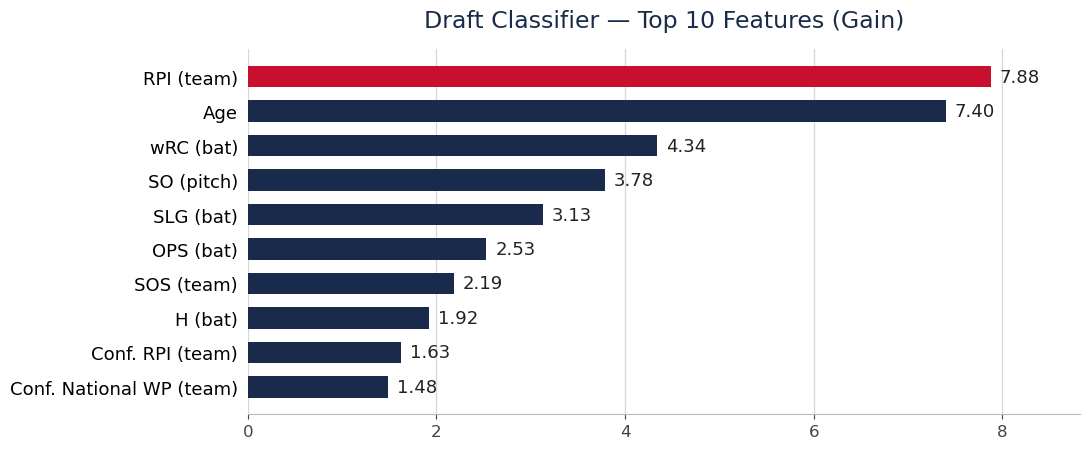

In [12]:
# Had AI help make this graphic to replicate the graphic used in the poster (same colors, font sizes, etc.)

# Stage 1 feature-importance bar chart (paper figure) — top N by gain, normalized to %

TOP_N       = 10
AS_PERCENT  = True       # values as % of total gain (matches the paper figure); False = raw gain
DECIMALS    = 2          # bar-label precision: 1 -> 3.7, 2 -> 3.67
N_HIGHLIGHT = 1          # color the top-N bars red
NAVY, RED   = '#1a2a4a', '#c8102e'

# raw column name -> display label
BASE_OVERRIDES = {       # acronym-only stats that need exact casing
    'rpi': 'RPI', 'conf_rpi': 'Conf. RPI', 'sos': 'SOS',
    'wrc': 'wRC', 'wrc+': 'wRC+', 'woba': 'wOBA', 'wraa': 'wRAA', 'wsb': 'wSB',
    'ops': 'OPS', 'slg': 'SLG', 'obp': 'OBP', 'iso': 'ISO', 'avg': 'AVG',
    'babip': 'BABIP', 'spd': 'Spd', 'fip': 'FIP', 'whip': 'WHIP', 'wpct': 'WPCT',
    'k/9': 'K/9', 'bb/9': 'BB/9', 'k/bb': 'K/BB', 'hr/9': 'HR/9', 'era': 'ERA',
    'k%': 'K%', 'bb%': 'BB%', 'k-bb%': 'K-BB%', 'lob%': 'LOB%', 'e-f': 'ERA-FIP',
}
_TOK = {'conf': 'Conf.', 'wp': 'WP', 'rpi': 'RPI', 'sos': 'SOS', 'pe': 'PE',
        'nc': 'NC', 'wpct': 'WPCT', 'rec': 'Rec', 'pct': '%',
        'q1': 'Q1', 'q2': 'Q2', 'q3': 'Q3', 'q4': 'Q4'}
def _fallback(base):     # cleans multi-word snake_case (e.g. conf_national_wp)
    out = []
    for p in base.split('_'):
        pl = p.lower()
        if pl in _TOK:                    out.append(_TOK[pl])
        elif len(p) <= 3 and p.isalpha(): out.append(p.upper())   # short -> acronym
        else:                             out.append(p.capitalize())
    return ' '.join(out)
def _pretty(col):
    if col == 'age':  return 'Age'
    if col == 'role': return 'Role'
    for suf in ('_bat', '_pitch', '_team'):
        if col.endswith(suf):
            base, grp = col[:-len(suf)], suf[1:]
            disp = BASE_OVERRIDES.get(base.lower()) or _fallback(base)
            return f"{disp} ({grp})"
    return BASE_OVERRIDES.get(col.lower()) or _fallback(col)

# gain importance from the trained classifier
gain  = draft_model.get_booster().get_score(importance_type='gain')
total = sum(gain.values()) if AS_PERCENT else 1.0
items = sorted(gain.items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]

labels = [_pretty(k) for k, _ in items][::-1]                       # reverse -> #1 at bottom
values = [(v / total * 100.0) if AS_PERCENT else v for _, v in items][::-1]
colors = [NAVY] * len(values)
for j in range(N_HIGHLIGHT):
    colors[-(j + 1)] = RED

fig, ax = plt.subplots(figsize=(11, 4.6))
y_pos = range(len(values))
ax.barh(y_pos, values, color=colors, height=0.62, zorder=3)

vmax = max(values)
for yi, v in zip(y_pos, values):
    ax.text(v + vmax * 0.012, yi, f"{v:.{DECIMALS}f}", va='center', ha='left',
            fontsize=13, color='#222222')

ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=13)
ax.set_xlim(0, vmax * 1.12)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.set_title(f'Draft Classifier \u2014 Top {TOP_N} Features (Gain)',
             fontsize=17, color=NAVY, pad=16)
ax.xaxis.grid(True, color='#d7d7d7', linewidth=0.9, zorder=0); ax.set_axisbelow(True)
for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#bbbbbb')
ax.tick_params(left=False); ax.tick_params(axis='x', labelsize=12, colors='#444444')
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/s1_feature_importance.png', dpi=200, bbox_inches='tight')
plt.savefig('figures/s1_feature_importance.pdf', bbox_inches='tight')
plt.show()

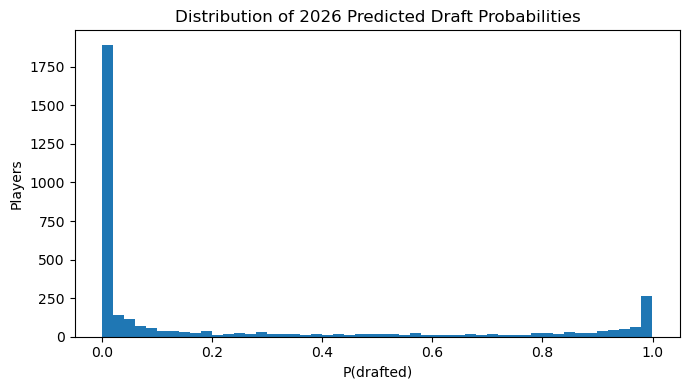

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(pred_df['draft_prob'], bins=50, color='#1f77b4')
plt.title(f'Distribution of {PREDICT_YEAR} Predicted Draft Probabilities')
plt.xlabel('P(drafted)'); plt.ylabel('Players')
plt.tight_layout(); plt.show()

In [14]:
# Parallel coordinates of pitching features, colored by predicted 2026 draft probability
pcp_features = ['rpi_team', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']
pcp_df = pred_df[pcp_features].copy()
pcp_df['Draft_Probability'] = pred_df['draft_prob'].values
pcp_df = pcp_df.dropna(subset=pcp_features)
print(f'Plotting {len(pcp_df)} players with complete pitching features')

fig = px.parallel_coordinates(
    pcp_df, color='Draft_Probability', dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],
    title=f'Parallel Coordinates: {PREDICT_YEAR} Pitching Features by Predicted Draft Probability'
)
fig.update_layout(width=1000, height=500)
fig.show()

Plotting 1118 players with complete pitching features


/opt/anaconda3/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 119 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



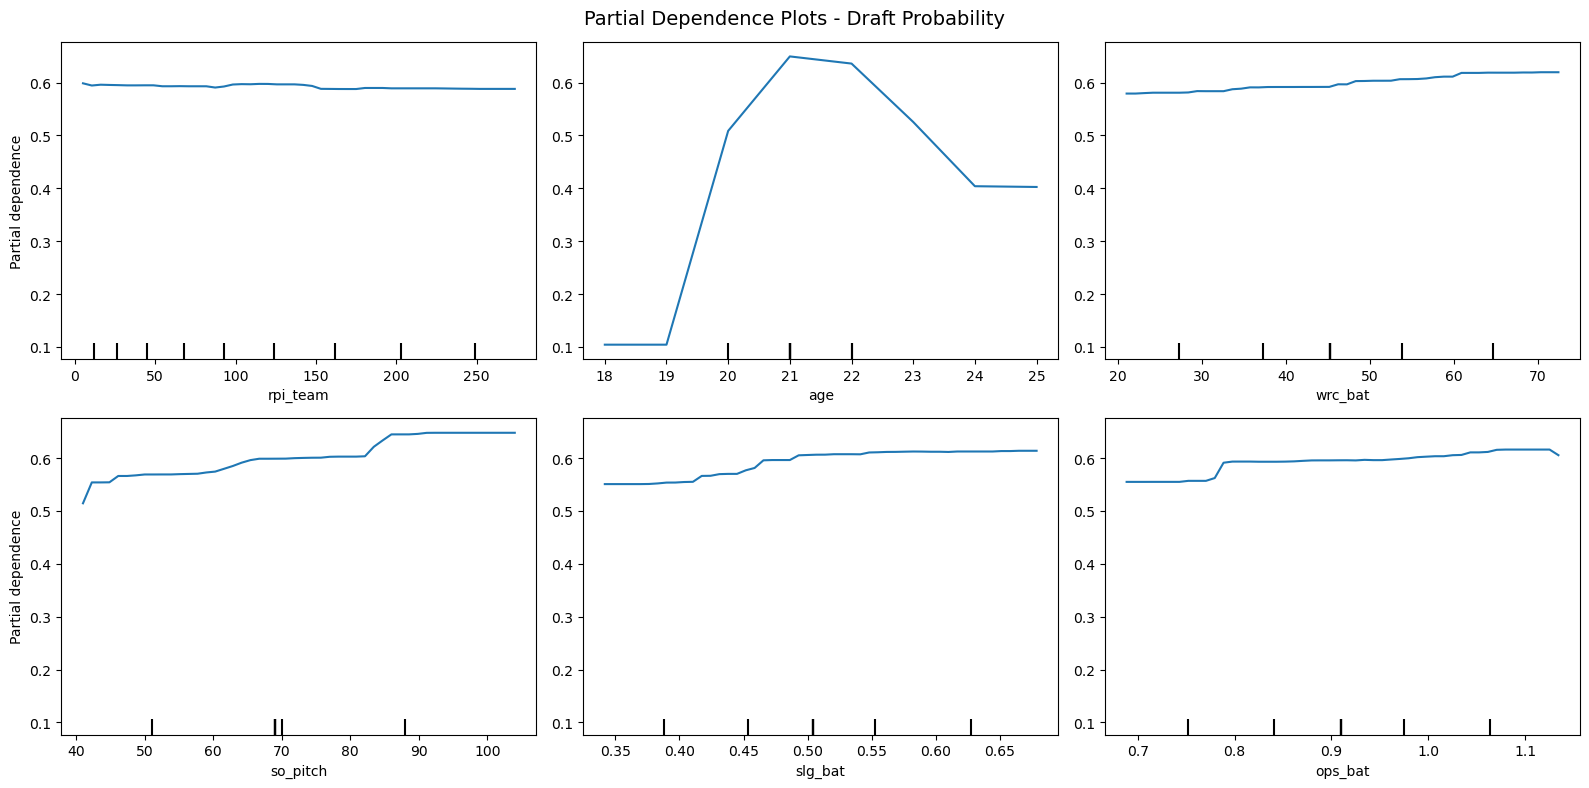

In [15]:
# Partial Dependence Plots - Draft Probability Classifier
top_n = 6
importances = draft_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:top_n].tolist()

# Fill NaN with median so sklearn can compute PDP grid (doesn't affect model)
X_pdp = X_balanced.fillna(X_balanced.median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    draft_model, X_pdp, features=top_indices,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)

# Keep the y-label only on the left column; clear it everywhere else
for ax in axes[:, 1:].flatten():
    ax.set_ylabel('')

fig.suptitle('Partial Dependence Plots - Draft Probability', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 119 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



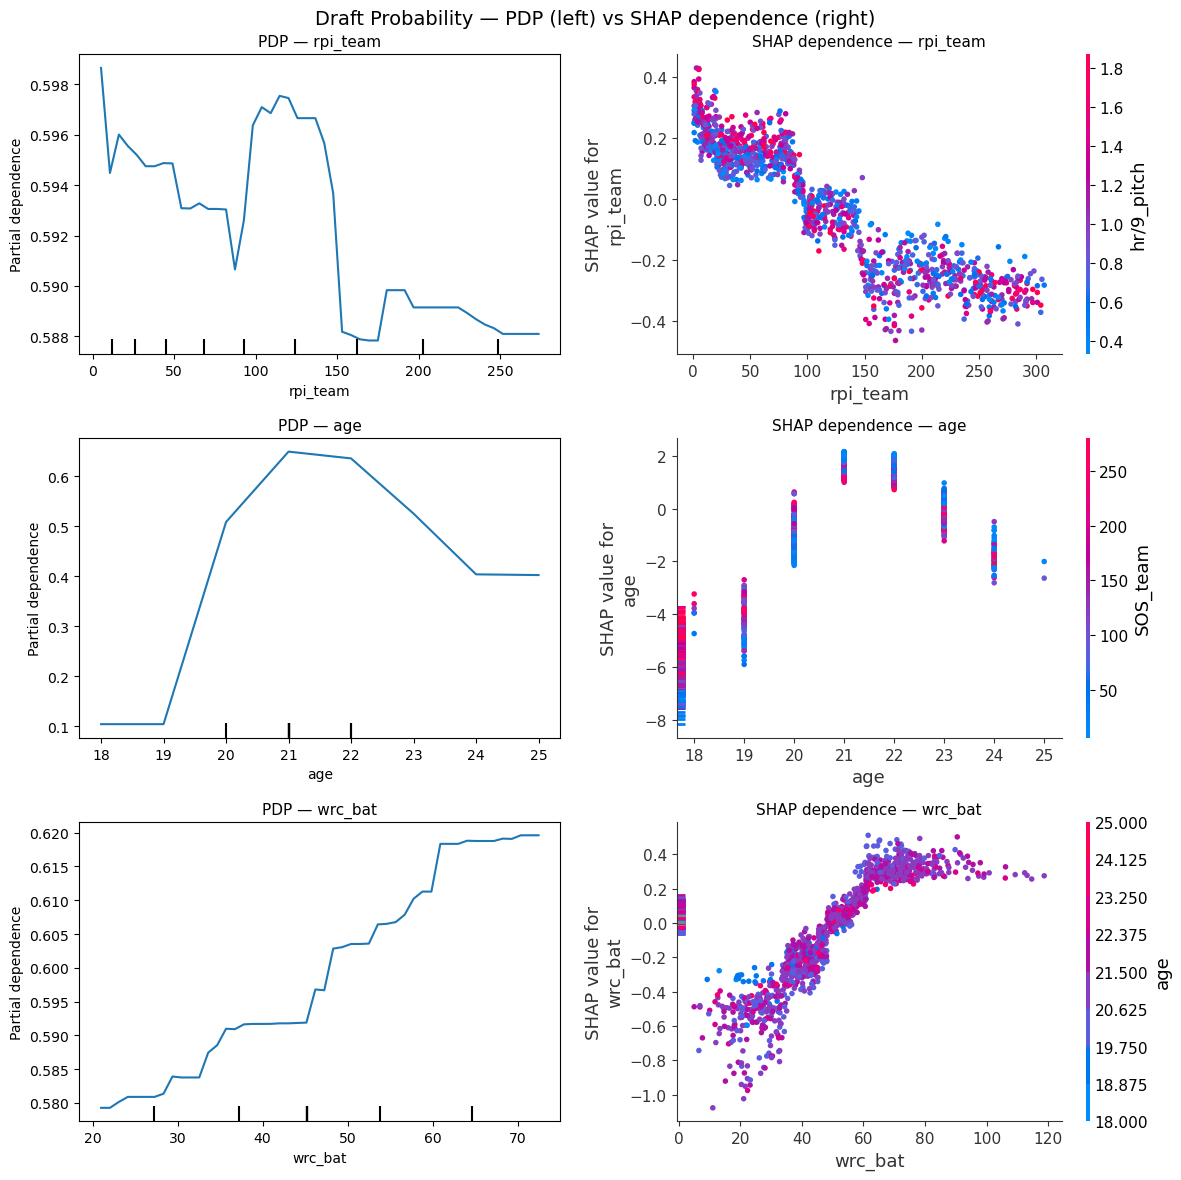

In [16]:
# AI CREATE SOME SHAP DEPENDENCE PLOTS

# Top features shared by both columns
top_n = 3
importances = draft_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:top_n].tolist()
top_names = X_balanced.columns[top_indices].tolist()

# PDP needs a NaN-free grid; SHAP can use the real (NaN-containing) data
X_pdp = X_balanced.fillna(X_balanced.median())

# Compute SHAP once, reuse for every right-column panel (TreeExplainer is exact + fast for XGB)
explainer = shap.TreeExplainer(draft_model)
shap_exp = explainer.shap_values(X_balanced)
if isinstance(shap_exp, list):      # older SHAP returns [class0, class1]
    shap_exp = shap_exp[1]          # keep positive (drafted) class

fig, axes = plt.subplots(top_n, 2, figsize=(12, 4 * top_n))

for row, (idx, name) in enumerate(zip(top_indices, top_names)):
    # Left: partial dependence
    PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp, features=[idx],
        kind='average', ax=axes[row, 0], grid_resolution=50
    )
    axes[row, 0].set_title(f'PDP — {name}', fontsize=11)

    # Right: SHAP dependence on real data, auto-colored by top interaction
    shap.dependence_plot(
        idx, shap_exp, X_balanced,
        ax=axes[row, 1], show=False, interaction_index='auto'
    )
    axes[row, 1].set_title(f'SHAP dependence — {name}', fontsize=11)

fig.suptitle('Draft Probability — PDP (left) vs SHAP dependence (right)', fontsize=14)
plt.tight_layout()
plt.show()

Top 6 features for PDP: ['rpi_team', 'age', 'wrc_bat', 'so_pitch', 'slg_bat', 'ops_bat']


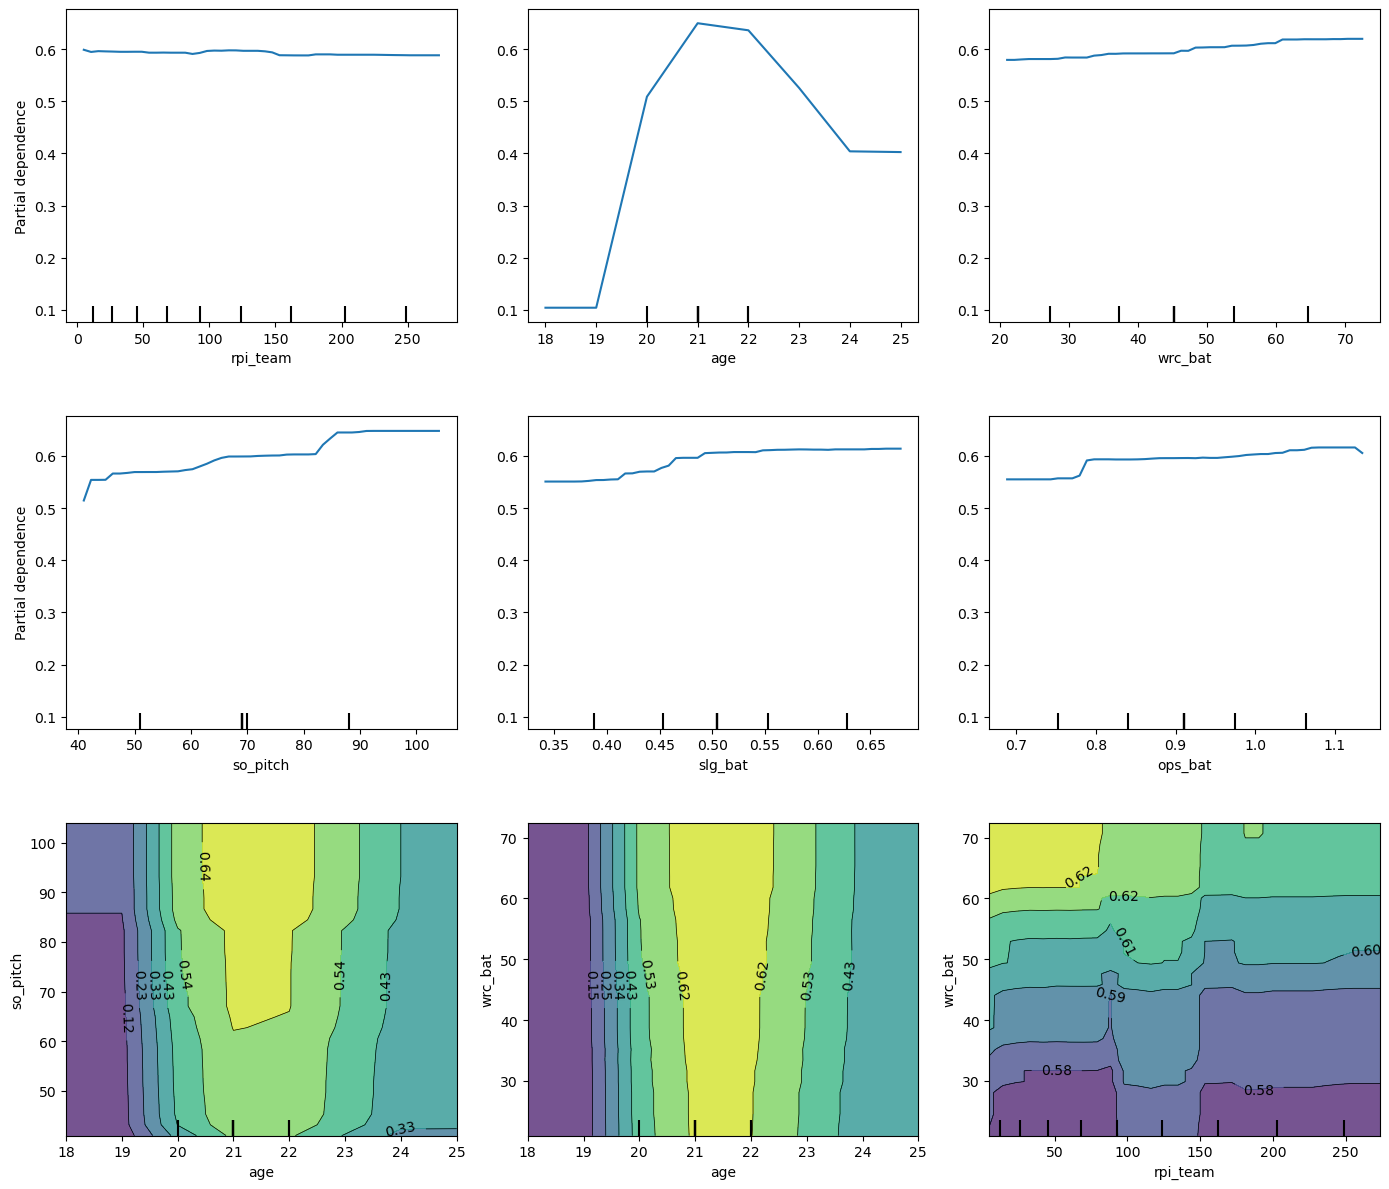

In [17]:
# USED AI TO MAKE GRAPHIC FOR PAPER

# Get top features dynamically (for 1D PDPs only)
top_indices = np.argsort(draft_model.feature_importances_)[::-1][:6].tolist()
top_names = [X_balanced.columns[i] for i in top_indices]
print("Top 6 features for PDP:", top_names)  # Sanity check

# Always use these exact interaction concepts for bottom-row 2D PDPs
cols = X_balanced.columns.tolist()

def find_best(cols, pattern_groups):
    for pats in pattern_groups:
        for c in cols:
            low = c.lower()
            if all(p.lower() in low for p in pats):
                return c
    return None

age_col = 'age'
so_col  = 'so_pitch'
wrc_col = 'wrc_bat'
rpi_col = 'rpi_team'

missing = [
    name for name, found in [
        ('age', age_col),
        ('strikeouts', so_col),
        ('wRC', wrc_col),
        ('team RPI', rpi_col),
    ] if not found
]
if missing:
    raise ValueError(f"Missing required columns for fixed 2D PDPs: {missing}")

# Fixed bottom-row pairs (independent of feature importance ordering)
pairs = [
    (age_col, so_col),    # age x strikeouts
    (age_col, wrc_col),   # age x wRC
    (rpi_col, wrc_col),   # team RPI x wRC
]

X_pdp = X_balanced.fillna(X_balanced.median()).astype(float)

# Single combined figure: 2 rows 1D, 1 row 2D
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# Top two rows: 1D PDPs for top 6 features
PartialDependenceDisplay.from_estimator(
    draft_model, X_pdp,
    features=top_indices,
    kind='average',
    ax=axes[:2].flatten(),
    grid_resolution=50
)

# Bottom row: fixed 2D interaction PDPs
for ax, pair in zip(axes[2], pairs):
    PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp,
        features=[pair],
        kind='average',
        ax=ax,
        grid_resolution=30
    )

# Keep "Partial dependence" only on the left 1D column (top two rows).
# Bottom-row y-labels are feature names, so leave them alone.
for ax in axes[:2, 1:].flatten():
    ax.set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

row2_bottom = axes[1, 0].get_position().y0
row3_top    = axes[2, 0].get_position().y1
divider_y   = (row2_bottom + row3_top) / 2

plt.savefig('figures/s1_pdp.pdf', bbox_inches='tight', dpi=200)
plt.savefig('figures/s1_pdp.png', bbox_inches='tight', dpi=200)
plt.show()

---
## Predicted Draft Order (Rank Model)

A stats-only regressor learns each historical draftee's within-year college draft order, then ranks the predicted 2026 class. MLB-API features (position/height/weight) are excluded so the model is applicable to players who haven't been drafted yet.

In [18]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,name,team,age,nameascii,playerid,mlbamid,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Acronym,Full Team Name,Round,Pick,Drafted By,Drafted From,Drafted?,Full Name_team,id_team,division_team,team_old,team_new,team_teamstats,league_team,conf_rpi_team,conf_rank_team,conf_national_rec_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,Difference_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,rpi_team,Conference_Record_team,Conference_Record_Wins_team,Conference_Record_Losses_team,SOS_team,NC_Rec_team,NC_Rec_Wins_team,NC_Rec_Losses_team,NC_RPI_team,NC_SOS_team,Home_team,Home_Wins_team,Home_Losses_team,Road_team,Road_Wins_team,Road_Losses_team,Neutral_team,Neutral_Wins_team,Neutral_Losses_team,Q1_team,Q1_Wins_team,Q1_Losses_team,Q2_team,Q2_Wins_team,Q2_Losses_team,Q3_team,Q3_Wins_team,Q3_Losses_team,Q4_team,Q4_Wins_team,Q4_Losses_team,total_college_seasons,Conference_Record_WP_team,NC_Rec_WP_team,Home_WP_team,Road_WP_team,Neutral_WP_team,Q1_WP_team,Q2_WP_team,Q3_WP_team,Q4_WP_team,PE_pct_team
2,a.j. causey,TENN,21.0,A.J. Causey,sa3028661,822067.0,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,TENN,university of tennessee knoxville,5.0,138.0,Kansas City Royals,university of tennessee,1,University of Tennessee Knoxville,871.0,1.0,Tennessee,University of Tennessee Knoxville,Tennessee,SEC,0.5886,1.0,279-62,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,0.015,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,1,22-8,22,8,12,24-2,24,2,10,73,40-4,40,4,9-6,9,6,11-3,11,3,26-10,26,10,9-1,9,1,5-1,5,1,20-1,20,1,3,0.733333,0.923077,0.909091,0.600000,0.785714,0.722222,0.900000,0.833333,0.952381,0.981752
22,aaron brown,MTSU,22.0,Aaron Brown,sa3017500,676345.0,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MTSU,middle tennessee state university,9.0,268.0,Houston Astros,middle tennessee state university,1,Middle Tennessee State University,527.0,1.0,Middle Tenn.,Middle Tennessee State University,Middle Tenn.,CUSA,0.5129,6.0,132-108,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,-0.039,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,216,12-19-1,12,19,231,11-8,11,8,199,251,14-12-1,14,12,9-15,9,15,1-2,1,2,1-9-0,1,9,3-5-0,3,5,4-

In [19]:
# USED AI TO LOAD AND MERGE MLB Stats API draft data for pick prediction

def load_draft_jsons(json_dir: str) -> pd.DataFrame:
    """Load all mlb_draft_YYYY.json files and flatten into a DataFrame."""
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)

        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            print(f"    ⚠️ No draftYear found, skipping")
            continue

        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}

                ov = pick.get("pickOverall") or pick.get("displayPickNumber")

                rows.append({
                    "year": int(draft_year),
                    "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"),
                    "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": float(pick["pickValue"]) / 1e6 if pick.get("pickValue") else None,
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ No picks loaded! Check your JSON_DIR path and file contents.")
        return df
    return df.drop_duplicates(subset=["year", "Pick"])


def name_similarity(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)


def height_to_inches(h):
    if pd.isna(h):
        return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError):
        return None


# ── Load JSONs ────────────────────────────────────────────────────────
JSON_DIR = "./MLBStatsAPIDraftDataAccess"

print(f"Looking in: {os.path.abspath(JSON_DIR)}")
print(f"Files found: {os.listdir(JSON_DIR)}\n")

api_df = load_draft_jsons(JSON_DIR)

print(f"\nAPI data: {len(api_df)} picks across years {sorted(api_df['year'].unique()) if not api_df.empty else 'NONE'}")
print(f"Drafted data: {len(drafted_df)} rows, Pick dtype={drafted_df['Pick'].dtype}, year dtype={drafted_df['year'].dtype}")

# ── Print unique string values before mapping ─────────────────────────
print(f"\nUnique api_batSide values:   {sorted(api_df['api_batSide'].dropna().unique())}")
print(f"Unique api_pitchHand values: {sorted(api_df['api_pitchHand'].dropna().unique())}")
print(f"Unique api_primaryPos values: {sorted(api_df['api_primaryPos'].dropna().unique())}")
print(f"Unique api_height values:    {sorted(api_df['api_height'].dropna().unique())}")

# ── Ensure matching dtypes ────────────────────────────────────────────
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)

if not api_df.empty:
    api_df["Pick"] = api_df["Pick"].astype(float)
    api_df["year"] = api_df["year"].astype(int)

    # Spot check: do the keys overlap?
    draft_keys = set(zip(drafted_df["year"], drafted_df["Pick"]))
    api_keys = set(zip(api_df["year"], api_df["Pick"]))
    overlap = draft_keys & api_keys
    print(f"\nKey overlap: {len(overlap)} matches out of {len(draft_keys)} drafted rows")

    # Merge
    drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")

    # Name match
    drafted_df["name_match_pct"] = drafted_df.apply(
        lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1
    )

    print(f"\nMatched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

    # Drop bad matches
    MATCH_THRESHOLD = 70
    low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
    if len(low_match) > 0:
        print(f"\n⚠️ Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%:")
        print(low_match[["year", "Pick", "nameascii", "api_name", "name_match_pct"]].to_string(index=False))

    drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
    print(f"\nRows remaining: {len(drafted_df)}")

    # ── Encode string columns to numeric ──────────────────────────────
    bat_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)

    pitch_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map(pitch_map)

    pos_map = {
        "C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5,
        "LF": 6, "RF": 7, "IF": 8, "1B": 9, "OF": 10, "DH": 11,
        "P": 12, "TWP": 13,
    }
    drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)

    drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

    # Verify
    print("\nConverted dtypes:")
    for col in ["api_batSide", "api_pitchHand", "api_primaryPos", "api_height", "api_weight"]:
        print(f"  {col}: {drafted_df[col].dtype}, unique: {sorted(drafted_df[col].dropna().unique())}")

else:
    print("\n❌ No API data loaded — nothing to merge.")

Looking in: /Users/mateobiggs/ncaaBaseballDraft-Predictor/CSV+Code Files/Main XGBoost Files/MLBStatsAPIDraftDataAccess
Files found: ['enrich_draft_dataV2.py', 'statsapi_draft_2026.json', 'statsapi_draft_2021.json', 'statsapi_teams.json', 'enrich_draft_data.py', 'statsapi_draft_2023.json', 'statsapi_draft_2022.json', 'statsapi_draft_2025.json', 'statsapi_draft_2024.json']

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_draft_2026.json...
  Loading statsapi_teams.json...
    ⚠️ No draftYear found, skipping

API data: 3685 picks across years [2021, 2022, 2023, 2024, 2025, 2026]
Drafted data: 1439 rows, Pick dtype=float64, year dtype=int64

Unique api_batSide values:   ['L', 'R', 'S']
Unique api_pitchHand values: ['L', 'R', 'S']
Unique api_primaryPos values: ['1B', '2B', '3B', 'C', 'CF', 'IF', 'LF', 'OF', 'P', 'RF', 'SS', 'TWP', '

In [20]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
592   2021       Henry Davis   1.0                    1           0.000000
644   2021       Jack Leiter   2.0                    2           0.003484
379   2021     Colton Cowser   5.0                    3           0.006969
1229  2021       Sam Bachman   9.0                    4           0.010453
902   2021      Kumar Rocker  10.0                    5           0.013937
1385  2021       Will Bednar  14.0                    6           0.017422
1226  2021       Sal Frelick  15.0                    7           0.020906
1035  2021  Michael McGreevy  18.0                    8           0.024390
579   2021    Gunnar Hoglund  19.0                    9           0.027875
1338  2021      Trey Sweeney  20.0                   10           0.031359
562   2021    Gavin Williams  23.0                   11           0.034843
1197  2021       Ryan Cusick  24.0                   12           0.03

In [21]:
# Stats-only draft-order models (no api_* features) so they apply to the 2026 class.
pick_features = [f for f in features if f not in redundant_features]

RANK_PARAMS = dict(
    n_estimators=600, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42
)

model_rank = xgb.XGBRegressor(**RANK_PARAMS)
model_rank.fit(draftedClean_df[pick_features], draftedClean_df['College_Draft_Order'])

model_rank_pct = xgb.XGBRegressor(**RANK_PARAMS)
model_rank_pct.fit(draftedClean_df[pick_features], draftedClean_df['College_Draft_Pct'])

print(f"Rank models trained on {len(draftedClean_df)} historical college draftees "
      f"(years {int(draftedClean_df[year_col].min())}-{int(draftedClean_df[year_col].max())}).")

Rank models trained on 1434 historical college draftees (years 2021-2025).


In [22]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                    Feature     Importance
0      #1                        age  100665.226562
1      #2                   so_pitch   78515.445312
2      #3                    SO_team   76600.859375
3      #4             conf_rank_team   62887.601562
4      #5                    wrc_bat   62256.757812
5      #6                   K/9_team   57253.949219
6      #7                k-bb%_pitch   46666.023438
7      #8                   rpi_team   44019.441406
8      #9                   bb/k_bat   37465.031250
9     #10              conf_rpi_team   36393.503906
10    #11                   k%_pitch   35348.230469
11    #12                  fip_pitch   32166.613281
12    #13                   wraa_bat   30451.718750
13    #14      conf_national_wp_team   29376.013672
14    #15                     sh_bat   28849.830078
15    #16                  K/BB_team   28296.398438
16    #17                    ops_bat   28117.404297
17    #18                    slg_ba

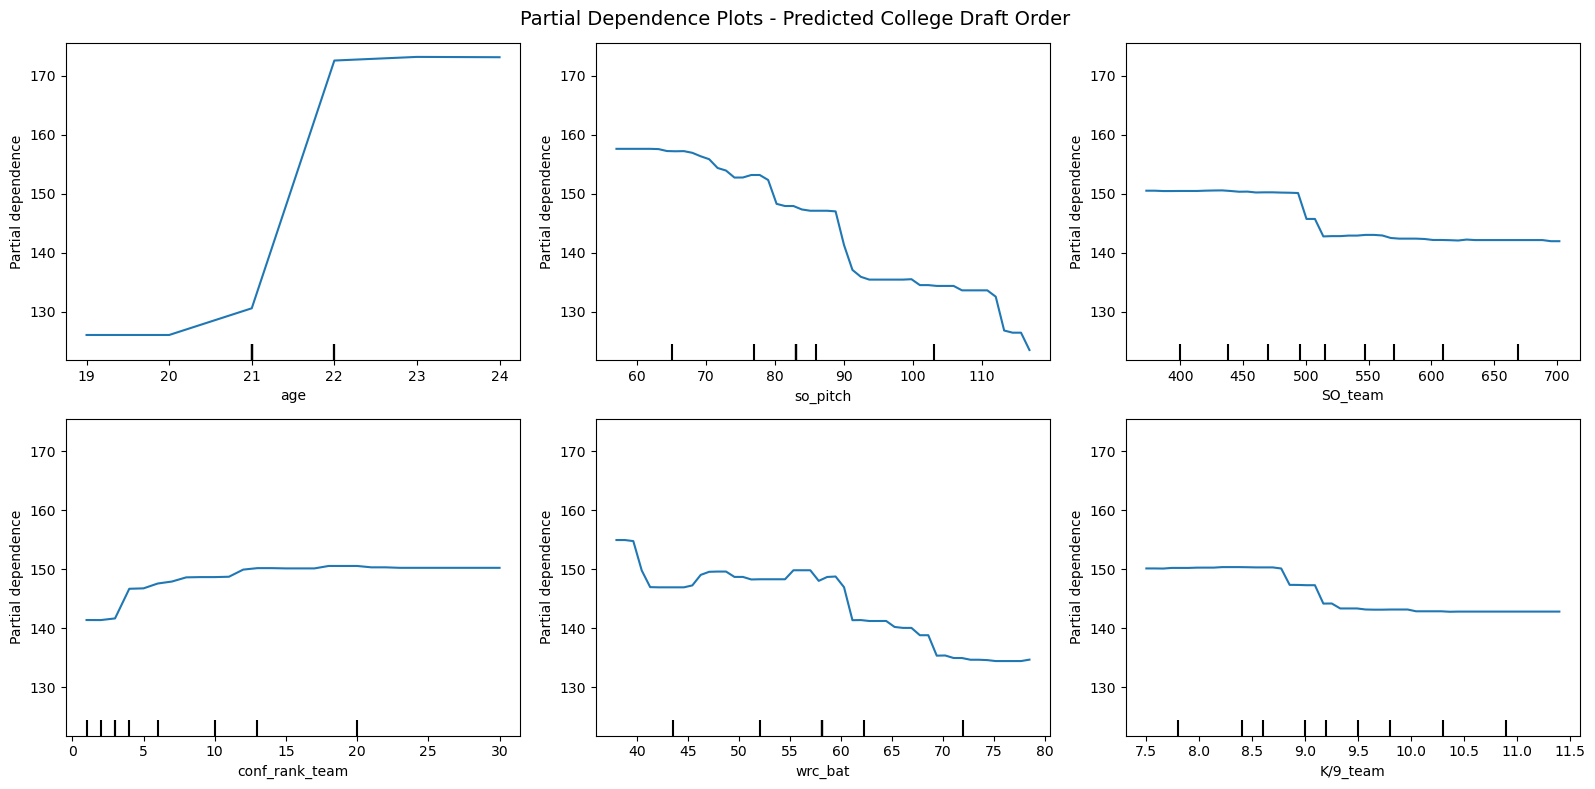

In [23]:
# Partial Dependence Plots - Predicted College Draft Order
top_n = 6
importances_rank = model_rank.feature_importances_
top_indices_rank = np.argsort(importances_rank)[::-1][:top_n].tolist()

X_pdp_rank = draftedClean_df[pick_features].fillna(draftedClean_df[pick_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    model_rank, X_pdp_rank, features=top_indices_rank,
    kind='average', ax=axes.flatten(), grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Predicted College Draft Order', fontsize=14)
plt.tight_layout(); plt.show()

In [24]:
# Predict raw draft-order score for every 2026 player (lower = earlier projected pick).
pred_df['rank_raw'] = model_rank.predict(X_2026)
pred_df['pred_pct'] = model_rank_pct.predict(X_2026)
print('2026 predicted draft-order score summary:')
print(pred_df['rank_raw'].describe().round(1))

2026 predicted draft-order score summary:
count    3492.0
mean      211.0
std        47.9
min        -2.3
25%       189.7
50%       220.6
75%       243.2
max       316.5
Name: rank_raw, dtype: float64


---
## Predicted Signing Bonus

Stats-only regressor on `log(signing bonus)` from historical draftees, applied to 2026.

In [25]:
# Signing-bonus model (stats only). Target from MLB Stats API historical data.
bonus_df = draftedClean_df[draftedClean_df['api_signingBonus'].notna()].copy()
bonus_df['log_signingBonus'] = np.log1p(bonus_df['api_signingBonus'] * 1e6)
bonus_features = [f for f in features if f not in redundant_features]

print(f'Players with signing-bonus data: {len(bonus_df)} / {len(draftedClean_df)}')

bonus_model = xgb.XGBRegressor(**RANK_PARAMS)
bonus_model.fit(bonus_df[bonus_features], bonus_df['log_signingBonus'])

pred_df['pred_bonus'] = np.expm1(bonus_model.predict(pred_df[bonus_features]))
print(f"Bonus model trained; 2026 predicted bonus range "
      f"${pred_df['pred_bonus'].min():,.0f} - ${pred_df['pred_bonus'].max():,.0f}")

Players with signing-bonus data: 1401 / 1434
Bonus model trained; 2026 predicted bonus range $3,306 - $5,494,658


In [26]:
# Show top features by importance from the trained classifier
importance = bonus_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                    Feature  Importance
0      #1                        age   57.773369
1      #2      conf_national_wp_team   15.143053
2      #3                   so_pitch   14.813296
3      #4                   wraa_bat   13.186481
4      #5                    wrc_bat   13.014157
5      #6              conf_rpi_team   11.072842
6      #7                    SO_team    8.647434
7      #8                   k%_pitch    7.539006
8      #9                   woba_bat    6.864671
9     #10                  fip_pitch    6.374197
10    #11                   rpi_team    6.367027
11    #12             conf_rank_team    6.190124
12    #13                   bb/k_bat    5.967311
13    #14                k-bb%_pitch    5.915599
14    #15                    ops_bat    5.854292
15    #16                   SOS_team    5.417807
16    #17                     hr_bat    5.348123
17    #18                      r_bat    4.853051
18    #19                   K/9_team    

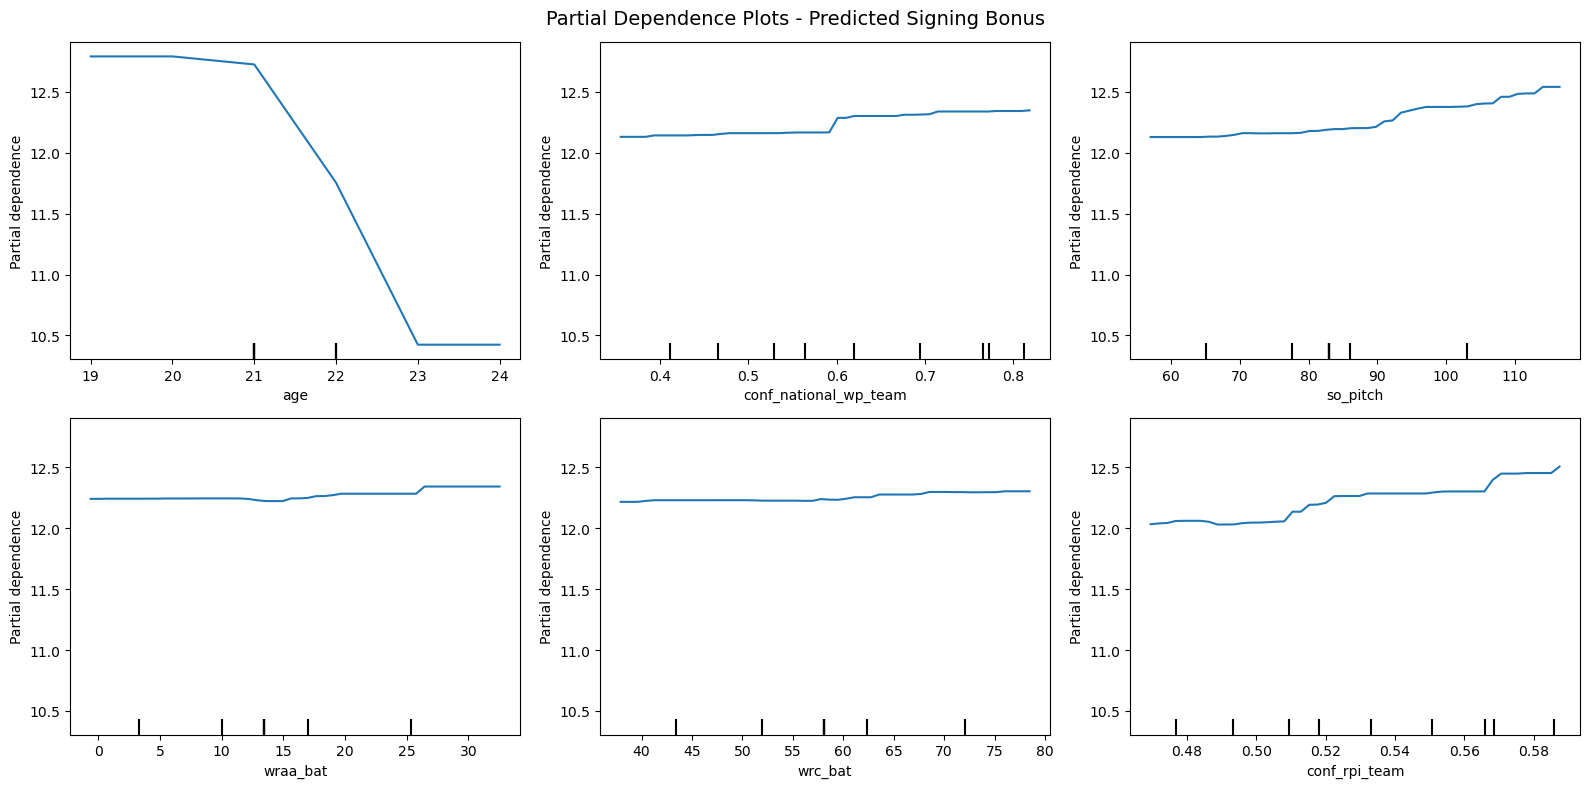

In [27]:
# Partial Dependence Plots - Predicted Signing Bonus
top_n = 6
importances_bonus = bonus_model.feature_importances_
top_indices_bonus = np.argsort(importances_bonus)[::-1][:top_n].tolist()

X_pdp_bonus = bonus_df[bonus_features].fillna(bonus_df[bonus_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    bonus_model, X_pdp_bonus, features=top_indices_bonus,
    kind='average', ax=axes.flatten(), grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Predicted Signing Bonus', fontsize=14)
plt.tight_layout(); plt.show()

---
## Predicted Slot Value & Bonus/Slot Ratio

Stats-only model for pick slot value; the bonus/slot ratio flags whether the model expects a player to sign over (>1) or under (<1) typical slot money.

In [28]:
# Slot-value model (stats only). Target: log(pick value) from MLB Stats API.
slot_df = draftedClean_df[draftedClean_df['api_pickValue'].notna()].copy()
slot_df['log_pickValue'] = np.log1p(slot_df['api_pickValue'] * 1e6)
slot_features = bonus_features

print(f'Players with pick-value data: {len(slot_df)} / {len(draftedClean_df)}')

slot_model = xgb.XGBRegressor(**RANK_PARAMS)
slot_model.fit(slot_df[slot_features], slot_df['log_pickValue'])

pred_df['pred_slot'] = np.expm1(slot_model.predict(pred_df[slot_features]))
pred_df['bonus_slot_ratio'] = pred_df['pred_bonus'] / pred_df['pred_slot'].clip(lower=1)
print('Slot model trained; 2026 predictions added.')

Players with pick-value data: 989 / 1434
Slot model trained; 2026 predictions added.


In [29]:
# Show top features by importance from the trained classifier
importance = slot_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                    Feature  Importance
0      #1                  WHIP_team  127.151527
1      #2                    HB_team  118.821243
2      #3                  k/9_pitch  107.109085
3      #4                   so_pitch   89.785431
4      #5                    SO_team   81.381027
5      #6                   wraa_bat   76.060928
6      #7                        age   66.201942
7      #8                   wrc+_bat   65.065971
8      #9                   k%_pitch   63.410080
9     #10                     pa_bat   60.787399
10    #11                    HR_team   58.704601
11    #12             conf_rank_team   58.506481
12    #13                   K/9_team   58.272709
13    #14                 Q1_WP_team   52.249569
14    #15                   bb/k_bat   52.084614
15    #16                   SHO_team   51.858509
16    #17       BBPG (Pitching)_team   50.312328
17    #18                     sh_bat   49.994495
18    #19                    IP_team   4

---
## 2026 Predicted Draft Board

Players with draft probability >= the threshold form the predicted draft class, ordered by the rank model. The full scored list (every 2026 player) is saved to `2026_draft_predictions.csv`.

In [30]:
# ---- 2026 Predicted Draft Board (website-ready) ----
# The classifier and rank model answer different questions, so combine them coherently:
#   1) GATE by classifier confidence (P(draft) >= PROB_GATE)  -> removes low-prob intrusions
#   2) FILTER to draft-eligible players (see eligibility cell)  -> removes ineligible underclassmen
#   3) ORDER survivors by the rank model (the mock-draft signal, reliable near the top)
#   4) CAP at BOARD_SIZE  (~ the ~288 college players actually drafted each year)
PROB_GATE  = 0.90
BOARD_SIZE = 300

# Eligibility: age >= 21 (turns 21 within ~45 days of the draft) OR 3rd+ college season (junior+).
AGE_ELIGIBLE = 21
CLASS_ELIGIBLE_SEASONS = 3

def _eligibility_basis(row):
    class_ok = row['total_college_seasons'] >= CLASS_ELIGIBLE_SEASONS
    age_ok = pd.notna(row['age']) and row['age'] >= AGE_ELIGIBLE
    if class_ok:
        return 'class'          # completed junior year (3rd+ season)
    if age_ok:
        return 'age'            # 21+ within 45 days of draft
    if pd.isna(row['age']):
        return 'unknown'        # no age on record and < 3 seasons -> cannot confirm
    return 'ineligible'         # < 21 and < 3 seasons -> underclassman, not yet eligible

pred_df['eligibility_basis'] = pred_df.apply(_eligibility_basis, axis=1)
pred_df['eligible'] = pred_df['eligibility_basis'].isin(['class', 'age'])

role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}
scored = pred_df.copy()
scored['role_name'] = scored['role'].map(role_name).fillna('Two-Way')
scored['conference'] = scored['league_team']

# Everyone who clears the confidence gate, ordered by the rank model (pre-eligibility).
gated = scored[scored['draft_prob'] >= PROB_GATE].sort_values('rank_raw').reset_index(drop=True)
gated['raw_board_pos'] = range(1, len(gated) + 1)   # where they'd sit on an unfiltered board

# Headline board: eligible only, re-numbered 1..N.
board = gated[gated['eligible']].head(BOARD_SIZE).reset_index(drop=True)
board['Predicted_Draft_Order'] = range(1, len(board) + 1)
board['Tier'] = board['Predicted_Draft_Order'].map(
    lambda p: 'Early' if p <= 50 else ('Middle' if p <= 150 else 'Late'))
drafted_board = board  # alias used by the visualization / lookup cells below

# Website-ready board CSV: one coherent ordering + a single confidence badge
out = board[['Predicted_Draft_Order', 'Tier', 'nameascii', 'team', 'conference',
             'role_name', 'draft_prob', 'pred_bonus']].rename(columns={
    'Predicted_Draft_Order': 'Pick', 'nameascii': 'name',
    'role_name': 'role', 'draft_prob': 'draft_prob_pct'})
out['draft_prob_pct'] = (out['draft_prob_pct'] * 100).round(1)
out['pred_bonus'] = out['pred_bonus'].round(0)
out.to_csv('2026_draft_predictions.csv', index=False)

# Full scored list (every 2026 player) + eligibility columns for transparency/audit.
full = scored.copy()
full['role'] = full['role'].map(role_name).fillna('Two-Way')
(full[['nameascii', 'team', 'league_team', 'role', 'draft_prob',
       'rank_raw', 'pred_pct', 'pred_bonus', 'pred_slot',
       'age', 'total_college_seasons', 'eligible', 'eligibility_basis']]
   .sort_values('draft_prob', ascending=False)
   .to_csv('2026_draft_predictions_full.csv', index=False))

# High-confidence players removed for eligibility (elite talent bound for a future draft).
ineligible = gated[~gated['eligible']].copy()
inelig_out = (ineligible[['raw_board_pos', 'nameascii', 'team', 'conference', 'role_name',
                          'draft_prob', 'age', 'total_college_seasons', 'eligibility_basis']]
              .rename(columns={'raw_board_pos': 'unfiltered_pick', 'nameascii': 'name',
                               'role_name': 'role'}))
inelig_out['draft_prob'] = (inelig_out['draft_prob'] * 100).round(1)
inelig_out.to_csv('2026_ineligible_underclassmen.csv', index=False)

print(f"Gate: {len(gated)} players with P(draft) >= {PROB_GATE:.0%}.")
print(f"  eligible: {int(gated['eligible'].sum())}  |  removed (ineligible/unknown): {int((~gated['eligible']).sum())}")
print(f"2026 board: {len(out)} eligible players, ordered by rank model, capped at {BOARD_SIZE}.")
print(f"  eligibility basis on board: "
      + ", ".join(f"{k}={v}" for k, v in board['eligibility_basis'].value_counts().items()))
print(f"Lowest draft prob on board: {out['draft_prob_pct'].min():.0f}%")
print(f"Last guy: #{int(out['Pick'].iloc[-1])} {out['name'].iloc[-1]} ({out['team'].iloc[-1]})")
print(f"Removed for eligibility ({len(inelig_out)}); top by rank model:")
print(inelig_out.head(10).to_string(index=False))
print("Saved: 2026_draft_predictions.csv (board) + 2026_draft_predictions_full.csv (all scored) "
      "+ 2026_ineligible_underclassmen.csv (high-conf but ineligible)")
pd.set_option('display.max_rows', None)
display(out.head(50))


Gate: 456 players with P(draft) >= 90%.
  eligible: 411  |  removed (ineligible/unknown): 45
2026 board: 300 eligible players, ordered by rank model, capped at 300.
  eligibility basis on board: class=215, age=85
Lowest draft prob on board: 90%
Last guy: #300 Max Vaisvila (NIU)
Removed for eligibility (45); top by rank model:
 unfiltered_pick            name team     conference    role  draft_prob  age  total_college_seasons eligibility_basis
               1  Dylan Volantis  TEX            SEC Pitcher   99.599998 20.0                      2        ineligible
               2  Brendan Lawson  FLA            SEC  Batter   98.099998 20.0                      2        ineligible
               4     Gavin Kelly  WVU         Big 12  Batter   98.199997 20.0                      2        ineligible
               6 Landon Hairston  ASU         Big 12  Batter   96.500000 20.0                      2        ineligible
               7 Andreas Alvarez  AUB            SEC Pitcher   99.699997 20.0

,Pick,Tier,name,team,conference,role,draft_prob_pct,pred_bonus
0,1,Early,Vahn Lackey,GT,ACC,Batter,91.199997,3710476.0
1,2,Early,Hunter Dietz,ARK,SEC,Pitcher,100.000000,3479136.0
2,3,Early,Drew Burress,GT,ACC,Batter,99.900002,2388080.0
3,4,Early,Liam Peterson,FLA,SEC,Pitcher,100.000000,1325139.0
4,5,Early,Jarren Advincula,GT,ACC,Batter,99.800003,2676945.0
5,6,Early,Tegan Kuhns,TENN,SEC,Pitcher,99.900002,1172805.0
6,7,Early,Cole Carlon,ASU,Big 12,Pitcher,100.000000,1685696.0
7,8,Early,Jake Schaffner,UNC,ACC,Batter,99.900002,1266235.0
8,9,Early,Owen Hull,UNC,ACC,Batter,99.900002,1360792.0
9,10,Early,Roch Cholowsky,UCLA,Big Ten,Batter,99.800003,1161621.0


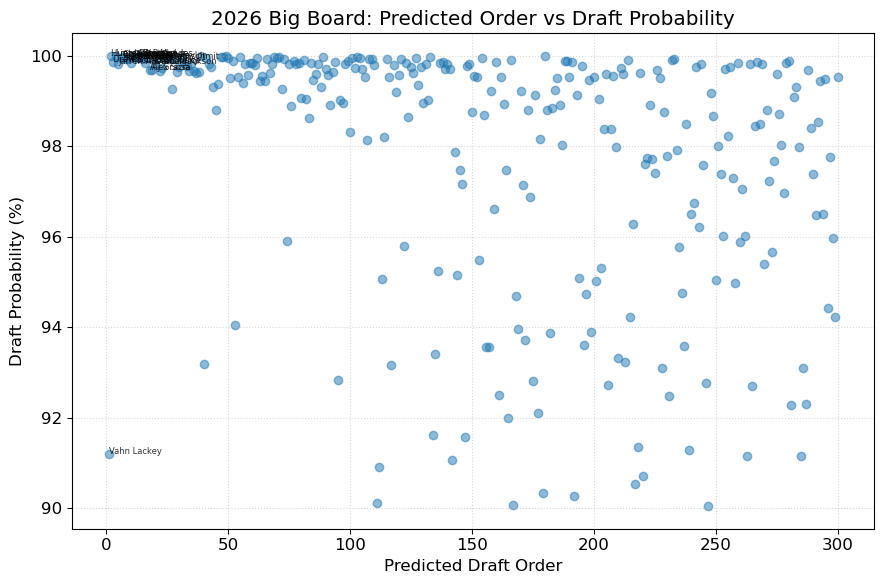

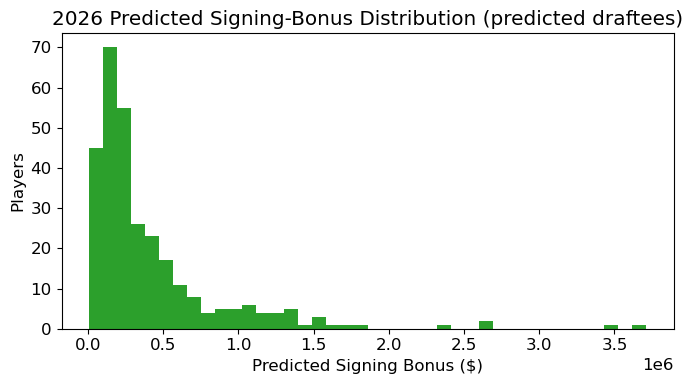

In [31]:
# Big-board scatter: predicted draft order vs draft probability (top 20 annotated)
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 6))
plt.scatter(drafted_board['Predicted_Draft_Order'], drafted_board['draft_prob'] * 100,
            alpha=0.5, color='#1f77b4')
for _, r in drafted_board.head(20).iterrows():
    plt.annotate(r['nameascii'], (r['Predicted_Draft_Order'], r['draft_prob'] * 100),
                 fontsize=6, alpha=0.8)
plt.xlabel('Predicted Draft Order'); plt.ylabel('Draft Probability (%)')
plt.title(f'{PREDICT_YEAR} Big Board: Predicted Order vs Draft Probability')
plt.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

# Predicted signing-bonus distribution for the predicted class
plt.figure(figsize=(7, 4))
plt.hist(drafted_board['pred_bonus'], bins=40, color='#2ca02c')
plt.xlabel('Predicted Signing Bonus ($)'); plt.ylabel('Players')
plt.title(f'{PREDICT_YEAR} Predicted Signing-Bonus Distribution (predicted draftees)')
plt.tight_layout(); plt.show()

---
## Per-Player Scouting Reports & Lookup

Explainable per-player output: draft grade, projected pick, signing bonus, and the stats driving each prediction. `lookup_player(name, year=2026)` works on any 2026 player; `predict_from_stats(...)` scores a custom stat line.

In [32]:
# Scouting Report -- explainer setup (run once)
# Builds the SHAP TreeExplainers (if shap is available), normalized feature
# importance dicts, training-set distributions for grading, a human label map,
# and a team-metadata frame re-loaded from the raw CSV (since cell 2 drops the
# team/Full Team Name/league_team columns from df to keep it numeric).

try:
    _HAS_SHAP = True
except Exception as _e:
    _HAS_SHAP = False
    print(f"shap unavailable ({_e.__class__.__name__}) -- falling back to importance x z-score only.")
    print("To enable SHAP: !pip install shap   (and ensure numpy<2 for the rest of this env)")

# Threshold below which the rank/bonus/slot predictions are suppressed in the
# scouting report -- the rank model is trained only on drafted players, so for
# clearly-not-drafted profiles those numbers are unreliable extrapolation.
MIN_DRAFT_PROB_FOR_PICK_DETAILS = 0.25

# Re-load just the team-metadata columns from the raw CSV. df has these dropped
# (cell 2) so it stays numeric for the models; we need them for the scouting header.
_team_meta = pd.read_csv(
    DATA_FILE,
    delimiter=',',
    usecols=['nameascii', 'year', 'team', 'Full Team Name', 'league_team'],
)
_team_meta_idx = (
    _team_meta.dropna(subset=['nameascii', 'year'])
              .drop_duplicates(subset=['nameascii', 'year'], keep='last')
              .set_index(['nameascii', 'year'])
)

def _get_player_team_meta(nameascii, year):
    """Return {team, Full Team Name, league_team} for (nameascii, year), or Nones."""
    try:
        row = _team_meta_idx.loc[(nameascii, int(year))]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        return {
            'team': row.get('team'),
            'Full Team Name': row.get('Full Team Name'),
            'league_team': row.get('league_team'),
        }
    except (KeyError, TypeError):
        return {'team': None, 'Full Team Name': None, 'league_team': None}

# Snapshot the *_team stat columns at setup time -- the Carbon Tracking cell at
# the end of the notebook reassigns df = pd.read_csv(emissions.csv), so any later
# call into get_team_stats would fail with KeyError on df['nameascii']. Build a
# frozen (team_lower, year) -> {*_team col: value} lookup right here, while df
# still points at the player frame.
_team_stat_cols = [c for c in df.columns if c.endswith('_team')]
_TEAM_STATS_BY_TEAM_YEAR = {}
for (_tc, _yr), _grp in (_team_meta
                         .dropna(subset=['nameascii', 'year', 'team'])
                         .groupby(['team', 'year'])):
    _na = _grp['nameascii'].iloc[0]
    _m = df[(df['nameascii'] == _na) & (df[year_col] == _yr)]
    if _m.empty:
        continue
    _row = _m.iloc[0]
    _TEAM_STATS_BY_TEAM_YEAR[(str(_tc).lower(), int(_yr))] = {
        col: _row[col] for col in _team_stat_cols
    }

# Training-set summary stats on the same split used for train_medians.
train_stds = df[df[year_col] < test_year].std(numeric_only=True)

# TreeExplainers (operate on raw model objects; very fast for XGBoost).
expl_draft = shap.TreeExplainer(draft_model) if _HAS_SHAP else None
expl_rank  = shap.TreeExplainer(model_rank)  if _HAS_SHAP else None

# Normalized gain-importance dicts (sum to 1.0).
def _normed_importance(model):
    raw = model.get_booster().get_score(importance_type='gain')
    total = sum(raw.values()) or 1.0
    return {k: v / total for k, v in raw.items()}

imp_draft = _normed_importance(draft_model)
imp_rank  = _normed_importance(model_rank)

# Training distributions for letter-grading the predictions.
_train_mask     = df[year_col] < test_year
_train_X_cls    = df.loc[_train_mask, features]
_train_drafted  = draftedClean_df[draftedClean_df[year_col] < test_year]
_train_X_rank   = _train_drafted[pick_features]
_train_draft_probs = draft_model.predict_proba(_train_X_cls)[:, 1]
_train_rank_preds  = model_rank.predict(_train_X_rank)

# Human-readable labels (raw column name -> short label).
FEATURE_LABELS = {
    'age': 'Age', 'role': 'Role',
    # Pitching
    'era_pitch': 'ERA',         'fip_pitch': 'FIP',
    'k/9_pitch': 'K/9',         'bb/9_pitch': 'BB/9',
    'k/bb_pitch': 'K/BB',       'whip_pitch': 'WHIP',
    'k%_pitch': 'K%',           'bb%_pitch': 'BB%',
    'k-bb%_pitch': 'K-BB%',     'ip_pitch': 'IP',
    'so_pitch': 'SO',           'bb_pitch': 'BB (pitch)',
    'h_pitch': 'H allowed',     'hr_pitch': 'HR allowed',
    'hr/9_pitch': 'HR/9',       'er_pitch': 'ER',
    'r_pitch': 'R allowed',     'avg_pitch': 'BA against',
    'babip_pitch': 'BABIP-against', 'lob%_pitch': 'LOB%',
    'e-f_pitch': 'ERA-FIP',     'sv_pitch': 'SV',
    'g_pitch': 'G (pitch)',     'gs_pitch': 'GS',
    'w_pitch': 'W',             'l_pitch': 'L',
    'tbf_pitch': 'TBF',         'hbp_pitch': 'HBP (pitch)',
    'wp_pitch': 'WP',           'bk_pitch': 'BK',
    'cg_pitch': 'CG',           'sho_pitch': 'SHO',
    # Batting
    'avg_bat': 'AVG',  'obp_bat': 'OBP',  'slg_bat': 'SLG',  'ops_bat': 'OPS',
    'iso_bat': 'ISO',  'woba_bat': 'wOBA','wrc+_bat': 'wRC+','wrc_bat': 'wRC',
    'wraa_bat': 'wRAA','hr_bat': 'HR',    'rbi_bat': 'RBI',  'r_bat': 'R',
    'h_bat': 'H',      '2b_bat': '2B',    '3b_bat': '3B',    '1b_bat': '1B',
    'bb%_bat': 'BB% (bat)',  'k%_bat': 'K% (bat)',
    'bb_bat': 'BB (bat)',    'so_bat': 'SO (bat)',
    'sb_bat': 'SB',          'cs_bat': 'CS',
    'babip_bat': 'BABIP',    'spd_bat': 'Spd',
    'g_bat': 'G (bat)',      'ab_bat': 'AB',  'pa_bat': 'PA',
    'hbp_bat': 'HBP (bat)',  'sf_bat': 'SF',  'sh_bat': 'SH',  'gdp_bat': 'GDP',
    'bb/k_bat': 'BB/K',      'wsb_bat': 'wSB',
}


def get_team_stats(team, team_year):
    """Return all *_team stats for a (team, team_year) pair, plus resolved metadata.

    Strict: `team` matches the raw-CSV `team` column case-insensitively (e.g. 'LSU',
    'USF'); `team_year` must exactly match `year`. Reads from the setup-time
    snapshot `_TEAM_STATS_BY_TEAM_YEAR` (not from df), so it stays correct even
    after the Carbon Tracking cell reassigns df to the emissions frame.

    Returns a flat dict for predict_from_stats(..., team_stats_dict=...). The
    `_resolved_*` keys carry display metadata and are ignored by the predictor.

    Raises ValueError if no match is found.
    """
    if team is None or team_year is None:
        raise ValueError("get_team_stats requires both `team` and `team_year`.")
    key = (str(team).lower(), int(team_year))
    stats = _TEAM_STATS_BY_TEAM_YEAR.get(key)
    if stats is None:
        codes = sorted({k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR})[:25]
        raise ValueError(
            f"No rows found for team={team!r} year={team_year}. "
            f"Try one of (first 25 codes): {codes}. "
            f"Full list: sorted({{k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR}})."
        )

    mask = (_team_meta['team'].astype(str).str.lower() == str(team).lower()) & (_team_meta['year'] == team_year)
    meta = _team_meta[mask].iloc[0]

    out = dict(stats)
    out['_resolved_team'] = str(meta['team']).upper()
    out['_resolved_team_year'] = int(team_year)
    full_name = meta.get('Full Team Name')
    out['_resolved_full_name'] = str(full_name).title() if pd.notna(full_name) else out['_resolved_team']
    league = meta.get('league_team')
    out['_resolved_conference'] = str(league) if pd.notna(league) else None
    return out


print("Explainer setup loaded.")
print(f"  SHAP available:        {_HAS_SHAP}")
print(f"  draft features:        {len(features)}    rank features: {len(pick_features)}")
print(f"  train baseline draft%: {_train_draft_probs.mean()*100:.1f}%")
print(f"  train rank dist:       median={np.median(_train_rank_preds):.1f}  "
      f"p10={np.percentile(_train_rank_preds,10):.1f}  p90={np.percentile(_train_rank_preds,90):.1f}")
print(f"  pick-detail threshold: {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% draft prob (below this, rank/bonus/slot are hidden)")
print(f"  team-meta rows loaded: {len(_team_meta):,}  (re-loaded from CSV; df has these columns dropped)")
print(f"  team-stats snapshot:   {len(_TEAM_STATS_BY_TEAM_YEAR):,} (team, year) pairs cached (survives df mutations)")
print(f"  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)")


Explainer setup loaded.
  SHAP available:        True
  draft features:        130    rank features: 130
  train baseline draft%: 20.8%
  train rank dist:       median=149.0  p10=47.1  p90=231.5
  pick-detail threshold: 25% draft prob (below this, rank/bonus/slot are hidden)
  team-meta rows loaded: 20,220  (re-loaded from CSV; df has these columns dropped)
  team-stats snapshot:   1,783 (team, year) pairs cached (survives df mutations)
  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)


In [33]:
# Scouting Report -- core functions
#   _explain_one(row, kind)  -> per-feature contribution records
#   _grade(percentile)       -> letter grade
#   scouting_report(row, draft_prob, rank_pred, name=..., team=..., conference=...)

def _label(feat):
    return FEATURE_LABELS.get(feat, feat)

def _fmt(value):
    if value is None: return '-'
    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value): return '-'
        return f"{value:.3f}" if abs(value) < 10 else f"{value:.1f}"
    return str(value)

def _rec_score(r):
    """Single sortable score per record: prefer SHAP, fall back to imp_z."""
    for k in ('shap_pct', 'shap_picks'):
        if r[k] is not None and not (isinstance(r[k], float) and np.isnan(r[k])):
            return r[k]
    return r['imp_z']

def _explain_one(row_series, model_kind):
    """Return contribution records sorted strengths-first (positive = good for the player)."""
    if model_kind == 'draft':
        feat_list, imp, explainer, sign_flip = features, imp_draft, expl_draft, 1.0
    elif model_kind == 'rank':
        feat_list, imp, explainer, sign_flip = pick_features, imp_rank, expl_rank, -1.0
    else:
        raise ValueError(model_kind)

    vals = row_series.reindex(feat_list).values
    x_df = pd.DataFrame([vals], columns=feat_list)

    shap_vals = None
    base = 0.0
    log_pred = 0.0
    if explainer is not None:
        sv = explainer.shap_values(x_df)
        if isinstance(sv, list):
            sv = sv[1]
        shap_vals = sv[0]
        ev = explainer.expected_value
        try:
            base = float(ev) if not hasattr(ev, '__len__') else float(ev[1] if len(ev) > 1 else ev[0])
        except (TypeError, ValueError):
            base = float(np.asarray(ev).ravel()[-1])
        log_pred = base + float(np.nansum(shap_vals))

    recs = []
    for i, feat in enumerate(feat_list):
        v = row_series.get(feat)
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        med = train_medians.get(feat, np.nan)
        std = train_stds.get(feat, np.nan)
        imp_z = 0.0 if (pd.isna(std) or std == 0) else imp.get(feat, 0.0) * float((v - med) / std) * sign_flip

        shap_pct = shap_picks = None
        if shap_vals is not None:
            s = float(shap_vals[i])
            if model_kind == 'draft':
                shap_pct = (expit(log_pred) - expit(log_pred - s)) * 100.0
            else:
                shap_picks = s * sign_flip

        recs.append({
            'feature': feat, 'label': _label(feat),
            'value': v, 'median': med,
            'shap_pct': shap_pct, 'shap_picks': shap_picks,
            'imp_z': imp_z,
        })

    recs.sort(key=_rec_score, reverse=True)
    return recs


def _draft_grade(draft_prob):
    """Map raw draft probability directly to a letter grade.

    Absolute thresholds (not training percentiles), so 0% -> F instead of D+:
        >= 90% A+   >= 80% A    >= 70% A-
        >= 60% B+   >= 50% B    >= 40% B-
        >= 30% C+   >= 20% C    >= 10% C-
        >=  5% D+   >=  2% D    >=  1% D-
        <   1% F
    Returns (letter, training_pct) -- training_pct is still computed so the report
    can show it as an auxiliary stat in parentheses.
    """
    p_pct = draft_prob * 100
    bands = [(90,'A+'),(80,'A'),(70,'A-'),(60,'B+'),(50,'B'),(40,'B-'),
             (30,'C+'),(20,'C'),(10,'C-'),(5,'D+'),(2,'D'),(1,'D-')]
    letter = 'F'
    for thresh, lbl in bands:
        if p_pct >= thresh:
            letter = lbl
            break
    train_pct = float((_train_draft_probs <= draft_prob).mean() * 100)
    return letter, train_pct


def _rank_grade(rank_pred):
    pct = float((_train_rank_preds >= rank_pred).mean() * 100)
    bins = [(95,'A+'),(88,'A'),(80,'A-'),(72,'B+'),(62,'B'),(54,'B-'),
            (46,'C+'),(38,'C'),(30,'C-'),(22,'D+'),(15,'D'),(8,'D-')]
    letter = 'F'
    for t, lbl in bins:
        if pct >= t:
            letter = lbl
            break
    return letter, pct


def _narrative(draft_letter, top_strength, top_concern, rank_pred, show_rank):
    band = {
        'A+':'a top profile', 'A':'an elite projection',
        'A-':'a strong projection', 'B+':'a sturdy projection',
        'B':'a solid projection', 'B-':'a mid projection',
        'C+':'a back-half projection', 'C':'a fringe projection',
        'C-':'a fringe-draftable profile', 'D+':'a long-shot draft profile',
        'D':'an undrafted-leaning profile', 'D-':'a Undrafted Free Agent (UDFA)-leaning profile',
        'F':'a clearly undrafted-leaning profile',
    }.get(draft_letter, 'a draftable profile')
    rank_phrase = f" (~pick {int(round(rank_pred))})" if show_rank else ""
    parts = [f"The model sees {band}{rank_phrase}."]
    if top_strength is not None:
        parts.append(f"Driven by {top_strength['label']} ({_fmt(top_strength['value'])} vs {_fmt(top_strength['median'])} median).")
    if top_concern is not None:
        parts.append(f"Main red flag: {top_concern['label']} ({_fmt(top_concern['value'])} vs {_fmt(top_concern['median'])} median).")
    return " ".join(parts)


def scouting_report(row_series, draft_prob, rank_pred, name=None, team=None, conference=None, top_n=5):
    """Print the scouting report block.

    row_series: pandas Series indexed by feature name (player or custom row).
    team/conference: optional strings shown right under the player name.
    """
    name = name or 'Custom Stat Line'
    show_rank = draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS

    d_letter, d_pct = _draft_grade(draft_prob)
    if show_rank:
        r_letter, r_pct = _rank_grade(rank_pred)

    draft_recs = _explain_one(row_series, 'draft')
    rank_recs  = _explain_one(row_series, 'rank') if show_rank else []

    strengths = [r for r in draft_recs if _rec_score(r) > 0][:top_n]
    concerns  = [r for r in reversed(draft_recs) if _rec_score(r) < 0][:top_n]
    top_s = strengths[0] if strengths else None
    top_c = concerns[0] if concerns else None

    sep = '=' * 64
    print(f"\n{sep}")
    print(f"  Scouting Report: {name}")
    if team or conference:
        parts = []
        if team:       parts.append(f"Team: {team}")
        if conference: parts.append(f"Conference: {conference}")
        print(f"  {'   '.join(parts)}")
    print(sep)
    print(f"  Draft Grade: {d_letter}   (P[draft]={draft_prob*100:.1f}%, "
          f"{d_pct:.0f}th pct of training preds)")
    if show_rank:
        print(f"  Rank  Grade: {r_letter}   (predicted pick ~{int(round(rank_pred))}, "
              f"{r_pct:.0f}th pct of training preds)")
    else:
        print(f"  Rank  Grade: -    (suppressed: draft prob < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}%)")
    print('-' * 64)
    print(f"  Take: {_narrative(d_letter, top_s, top_c, rank_pred, show_rank)}")

    def _print_block(title, recs, arrow):
        print()
        header = "    feature             value      vs median"
        if _HAS_SHAP: header += "      d-prob"
        header += "    imp x z"
        print(f"  {title}")
        print(header)
        if not recs:
            print("    (none)")
            return
        for r in recs:
            shap_part = ''
            if _HAS_SHAP and r['shap_pct'] is not None:
                shap_part = f"   {r['shap_pct']:+6.2f}%"
            elif _HAS_SHAP:
                shap_part = '          -'
            imp_part = f"   {r['imp_z']:+7.3f}"
            print(f"    {arrow} {r['label']:<16s}  {_fmt(r['value']):>8s}  "
                  f"(vs {_fmt(r['median']):>7s}){shap_part}{imp_part}")

    _print_block(f"Top {len(strengths)} STRENGTHS (boost draft stock)", strengths, '^')
    _print_block(f"Top {len(concerns)} CONCERNS  (drag it down)",        concerns,  'v')

    if show_rank:
        r_str = [r for r in rank_recs if _rec_score(r) > 0][:3]
        r_con = [r for r in reversed(rank_recs) if _rec_score(r) < 0][:3]
        print()
        print("  Rank-model cross-check (which features improve / hurt predicted pick):")
        print(f"    + improves pick: {', '.join(r['label'] for r in r_str) or '(none)'}")
        print(f"    - hurts pick:    {', '.join(r['label'] for r in r_con) or '(none)'}")
    print(sep)


In [34]:
train_medians = df[df[year_col] < test_year].median(numeric_only=True)

def _format_team_display(team_code, full_team_name):
    """Title-case the full team name; append the short code in parens if both exist."""
    has_full = pd.notna(full_team_name) and str(full_team_name).strip()
    has_code = pd.notna(team_code) and str(team_code).strip()
    if has_full and has_code:
        return f"{str(full_team_name).title()} ({str(team_code).upper()})"
    if has_full:
        return str(full_team_name).title()
    if has_code:
        return str(team_code).upper()
    return None

def lookup_player(name_query, year=None, explain=True):
    candidates = df if year is None else df[df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}.get(player['role'], '?')

    # team/Full Team Name/league_team were dropped from df in cell 2 to keep
    # df numeric; re-load them from _team_meta (built in cell 56 from the CSV).
    team_meta = _get_player_team_meta(player['nameascii'], int(player[year_col]))
    team_display = _format_team_display(team_meta['team'], team_meta['Full Team Name'])
    league = team_meta['league_team']
    conf_display = str(league) if pd.notna(league) else None

    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    if team_display or conf_display:
        bits = []
        if team_display: bits.append(f"Team: {team_display}")
        if conf_display: bits.append(f"Conference: {conf_display}")
        print('  ' + '   '.join(bits))
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")
    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat', 'bb%_bat', 'k%_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    cls_df = pd.DataFrame([player.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([player.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([player.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([player.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")
    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")

    if explain and 'scouting_report' in globals():
        scouting_report(player, draft_prob, rank_pred,
                        name=player['nameascii'],
                        team=team_display,
                        conference=conf_display)

    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")


lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [35]:
# Scouting reports for the top predicted 2026 prospects
for _nm in drafted_board['nameascii'].head(3).tolist():
    lookup_player(_nm, year=PREDICT_YEAR)

Player: Vahn Lackey  |  Year: 2026  |  Role: Batter
  Team: Georgia Institute Of Technology (GT)   Conference: ACC

--- Key Stats ---
  avg_bat: 0.397
  ops_bat: 1.291
  hr_bat: 20.0
  wrc+_bat: 170.3
  woba_bat: 0.541
  slg_bat: 0.772
  bb%_bat: 0.177
  k%_bat: 0.134

--- Predictions ---
Draft Probability: 91.2%
Predicted College Draft Order: ~2
Predicted College Draft Pct: 1.7%
Predicted Signing Bonus: $3,710,476
Predicted Slot Value: $1,202,889
Bonus/Slot Ratio: 3.08

Other matches: ['Nathan Beckley', 'Jaylon Lucky', 'Ethan Lay', 'Nathan Earley']

  Scouting Report: Vahn Lackey
  Team: Georgia Institute Of Technology (GT)   Conference: ACC
  Draft Grade: A+   (P[draft]=91.2%, 86th pct of training preds)
  Rank  Grade: A+   (predicted pick ~2, 100th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 2). Driven by wRAA (37.8 vs 2.055 median). Main red flag: Age (20.0 vs 21.0 median).

  Top 5 STRENGTHS (b

In [36]:
PITCHER_TEMPLATE = {
    'age': 21, 'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}
BATTER_TEMPLATE = {
    'age': 21, 'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def predict_from_stats(role, age, stats_dict, team_stats_dict=None,
                       team=None, team_year=None, explain=True, name=None):
    """Predict draft outcomes from a custom stat line.

    New optional kwargs:
      team, team_year -- when both are given AND team_stats_dict is None,
        get_team_stats(team, team_year) is called to auto-populate the team
        stats (and to label the scouting header). Strict match.
    """
    role_num = {'Pitcher': 0, 'Batter': 1, 'Both': 2}[role]

    resolved_team_display = None
    resolved_conference = None
    if team_stats_dict is None and team is not None and team_year is not None:
        team_stats_dict = get_team_stats(team, team_year)
        resolved_team_display = (
            f"{team_stats_dict['_resolved_full_name']} ({team_stats_dict['_resolved_team']})"
        )
        resolved_conference = team_stats_dict.get('_resolved_conference')
        print(f"Auto-loaded team stats: {team_stats_dict['_resolved_team']} "
              f"{team_stats_dict['_resolved_team_year']} "
              f"({resolved_conference or 'unknown conf'})")
    elif team is not None or team_year is not None:
        if team is None or team_year is None:
            raise ValueError("Pass both `team` and `team_year` together, or neither.")

    row = pd.Series(index=pick_features, dtype=float)
    row[:] = np.nan
    row['age'] = age; row['role'] = role_num
    for k, v in stats_dict.items():
        if k in row.index: row[k] = v
    if team_stats_dict:
        for k, v in team_stats_dict.items():
            if k in row.index: row[k] = v
    else:
        for f in row.index:
            if pd.isna(row[f]) and f.endswith('_team') and f in train_medians.index:
                row[f] = train_medians[f]

    cls_df = pd.DataFrame([row.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([row.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([row.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([row.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"{'='*50}")
    header = f"Custom {role} Prediction (age {age})"
    if resolved_team_display:
        header += f"  --  {resolved_team_display}"
    print(header)
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if explain and 'scouting_report' in globals():
        full_row = row.copy()
        for f in features:
            if f not in full_row.index:
                full_row[f] = np.nan
        for k, v in stats_dict.items():
            if k in features: full_row[k] = v
        if team_stats_dict:
            for k, v in team_stats_dict.items():
                if k in features: full_row[k] = v
        full_row['age'] = age; full_row['role'] = role_num
        scouting_report(full_row, draft_prob, rank_pred,
                        name=name or f"Custom {role} (age {age})",
                        team=resolved_team_display,
                        conference=resolved_conference)

    return {'draft_prob': draft_prob, 'pred_order': rank_pred, 'pred_pct': pct_pred,
            'pred_bonus': bonus_pred, 'pred_slot': slot_pred, 'bonus_slot_ratio': ratio}

print("predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")
print("  New: pass team='LSU', team_year=2024 to auto-populate team stats.")


predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE
  New: pass team='LSU', team_year=2024 to auto-populate team stats.


In [37]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Custom Pitcher Prediction (age 21)
Draft Probability: 99.8%
Predicted College Draft Order: ~101
Predicted College Draft Pct: 32.0%
Predicted Signing Bonus: $450,440
Predicted Slot Value: $1,151,990
Bonus/Slot Ratio: 0.39

  Scouting Report: Custom Pitcher (age 21)
  Draft Grade: A+   (P[draft]=99.8%, 98th pct of training preds)
  Rank  Grade: B   (predicted pick ~101, 71th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 101). Driven by Age (21.0 vs 21.0 median). Main red flag: NC_Rec_WP_team (0.500 vs 0.500 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ Age                   21.0  (vs    21.0)    +0.86%    +0.000
    ^ SO                   120.0  (vs    55.0)    +0.35%    +0.111
    ^ K%                   0.320  (vs   0.201)    +0.17%    +0.029
    ^ K-BB%                0.260  (vs   0.112)    +0.10%    +0.018
    ^ FIP          

{'draft_prob': 0.9984763,
 'pred_order': 101.39068,
 'pred_pct': 0.32035494,
 'pred_bonus': 450439.62,
 'pred_slot': 1151990.4,
 'bonus_slot_ratio': 0.3910099}

In [38]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Custom Batter Prediction (age 21)
Draft Probability: 98.9%
Predicted College Draft Order: ~153
Predicted College Draft Pct: 55.2%
Predicted Signing Bonus: $225,546
Predicted Slot Value: $918,799
Bonus/Slot Ratio: 0.25

  Scouting Report: Custom Batter (age 21)
  Draft Grade: A+   (P[draft]=98.9%, 93th pct of training preds)
  Rank  Grade: C+   (predicted pick ~153, 48th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 153). Driven by Age (21.0 vs 21.0 median). Main red flag: SOS_team (147.0 vs 147.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ Age                   21.0  (vs    21.0)    +5.70%    +0.000
    ^ OPS                  1.050  (vs   0.838)    +0.68%    +0.038
    ^ ISO                  0.280  (vs   0.161)    +0.39%    +0.010
    ^ K% (bat)             0.120  (vs   0.181)    +0.38%    -0.008
    ^ R                     

{'draft_prob': 0.9885168,
 'pred_order': 152.97528,
 'pred_pct': 0.5519097,
 'pred_bonus': 225545.9,
 'pred_slot': 918798.8,
 'bonus_slot_ratio': 0.2454791}

## Carbon Tracking

In [39]:
emissions = tracker.stop()

# Constants for equivalencies
CAR_EMISSION_FACTOR = 0.12        # kgCO2 per km
TV_DAILY_WH = 138                 # Wh per day
TV_EMISSION_FACTOR = 0.084        # kgCO2 per kWh (implied by source)
US_WEEKLY_KG = (13.3 * 1000) / 52  # kg CO2 per week for avg US citizen

energy_kwh = tracker.final_emissions_data.energy_consumed

print("\nCarbon Emissions Summary:")
print(f"  Total CO₂ emitted:     {emissions:.7f} kg")
print(f"  Total energy consumed: {energy_kwh:.7f} kWh")
print(f"  Total cost of energy:  ${tracker.final_emissions_data.energy_consumed*0.269141194:.7f} USD")
print(f"    CPU energy:          {tracker.final_emissions_data.cpu_energy:.7f} kWh")
print(f"    RAM energy:          {tracker.final_emissions_data.ram_energy:.7f} kWh")
_gpu_kwh = tracker.final_emissions_data.gpu_energy
def _nvidia_gpu_present():
    try:
        pynvml.nvmlInit()
        n = pynvml.nvmlDeviceGetCount()
        pynvml.nvmlShutdown()
        return n > 0
    except Exception:
        return False
if _gpu_kwh == 0 and not _nvidia_gpu_present():
    print(f"    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)")
else:
    print(f"    GPU energy:          {_gpu_kwh:.7f} kWh")
print(f"  Duration:              {tracker.final_emissions_data.duration:.2f} s")

print("\nEquivalency Estimates:")
print(f"  🚗 Car distance:       {emissions / CAR_EMISSION_FACTOR:.4f} km driven")
print(f"  📺 TV usage:           {(energy_kwh / (TV_DAILY_WH / 1000)):.4f} days of TV")
print(f"  🧍 US citizen:         {(emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")

# Cumulative stats from emissions.csv
EMISSIONS_CSV = os.path.join(os.getcwd(), "emissions.csv")

if os.path.exists(EMISSIONS_CSV):
    df = pd.read_csv(EMISSIONS_CSV)
    total_emissions = df["emissions"].sum()
    total_energy    = df["energy_consumed"].sum()
    total_duration  = df["duration"].sum()
    n_runs          = len(df)

    print(f"\nCumulative Summary ({n_runs} runs):")
    print(f"  Total CO₂ emitted:     {total_emissions:.7f} kg")
    print(f"  Total energy consumed: {total_energy:.7f} kWh")
    print(f"  Total cost of energy:  ${total_energy * 0.269141194:.7f} USD")
    print(f"  Total duration:        {total_duration:.2f} s ({total_duration/3600:.2f} hrs)")

    print("\nEquivalency Estimates (Cumulative):")
    print(f"  🚗 Car distance:       {total_emissions / CAR_EMISSION_FACTOR:.4f} km driven")
    print(f"  📺 TV usage:           {(total_energy / (TV_DAILY_WH / 1000)):.4f} days of TV")
    print(f"  🧍 US citizen:         {(total_emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")


Carbon Emissions Summary:
  Total CO₂ emitted:     0.0001131 kg
  Total energy consumed: 0.0003062 kWh
  Total cost of energy:  $0.0000824 USD
    CPU energy:          0.0002683 kWh
    RAM energy:          0.0000379 kWh
    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)
  Duration:              22.73 s

Equivalency Estimates:
  🚗 Car distance:       0.0009 km driven
  📺 TV usage:           0.0022 days of TV
  🧍 US citizen:         0.000044% of weekly per-capita emissions

Cumulative Summary (34 runs):
  Total CO₂ emitted:     0.0149171 kg
  Total energy consumed: 0.0403740 kWh
  Total cost of energy:  $0.0108663 USD
  Total duration:        3157.74 s (0.88 hrs)

Equivalency Estimates (Cumulative):
  🚗 Car distance:       0.1243 km driven
  📺 TV usage:           0.2926 days of TV
  🧍 US citizen:         0.005832% of weekly per-capita emissions
